# Air Quality Prediction Using Machine Learning and Data Mining Techniques

**Student:** Abdul Manan Tanveer,Haziq Mustafa,Daniyal Ahmad  **Reg #:** 2023-BS-AI-173,2023-BS-AI-181,2023-BS-AI-183  
**Program:** BS Artificial Intelligence  **Subject:** Data Mining

---

### What this notebook does (in plain words)
We use one year of real air-sensor readings from an Italian city (the **UCI Air Quality**
dataset) to **predict the concentration of Carbon Monoxide — CO(GT)** in the air from the
other sensor signals and weather conditions.

The notebook follows the standard Data Mining pipeline, one step per section:
1. Import libraries 2. Load data 3. Clean data 4. Explore data (EDA)
5. Select features 6. Split data 7. Train models 8. Evaluate models
9. Make a prediction 10. Conclusion

Just press **Run All** (or run each cell top-to-bottom with *Shift + Enter*).

## Step 1 — Import the libraries
Libraries are ready-made toolboxes. We load them once at the top.

In [1]:
# pandas  -> work with tables of data (like Excel in Python)
# numpy   -> fast maths on numbers and arrays
# matplotlib & seaborn -> draw graphs
# scikit-learn (sklearn) -> the machine-learning models and tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# make graphs look clean and consistent
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
from google.colab import files

uploaded = files.upload()

Saving air_quality_cleaned.csv to air_quality_cleaned.csv
Saving AirQualityUCI.csv to AirQualityUCI.csv


## Step 2 — Load the dataset
The data file `AirQualityUCI.csv` lives in the `Dataset` folder, one level above this
notebook, so the path is `../Dataset/AirQualityUCI.csv`.

**About the data:** 9,357 hourly readings (March 2004 – February 2005). Each pollutant has
a *true* reference value measured by a certified analyser, written as `(GT)` = *Ground Truth*,
and a matching low-cost **sensor** response, written as `PT08.Sx`. We also have temperature
`T`, relative humidity `RH` and absolute humidity `AH`.

In [3]:
import pandas as pd

df = pd.read_csv("AirQualityUCI.csv")

# the file has two empty trailing columns and some blank rows -> remove them
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df = df.dropna(how="all").reset_index(drop=True)

print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (9357, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10-03-2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10-03-2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10-03-2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10-03-2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10-03-2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [4]:
# Quick look at column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


## Step 3 — Clean the data (Data Pre-processing)
Two problems must be fixed before any model can learn:

1. **Missing values are written as `-200`** (not blank). We replace `-200` with `NaN`
   (Python's "empty"), then fill the gaps with the column **median** (a safe middle value).
2. **The `NMHC(GT)` column is almost entirely missing (~90%)**, so we drop it — keeping it
   would only add noise.

In [5]:

import numpy as np

# 1) turn the special code -200 into a real "missing" marker
df = df.replace(-200, np.nan)

# 2) show how much is missing in each column (as a %)
missing_pct = (df.isna().mean() * 100).round(1)
print("Missing % per column:")
print(missing_pct.to_string())

Missing % per column:
Date              0.0
Time              0.0
CO(GT)           18.0
PT08.S1(CO)       3.9
NMHC(GT)         90.2
C6H6(GT)          3.9
PT08.S2(NMHC)     3.9
NOx(GT)          17.5
PT08.S3(NOx)      3.9
NO2(GT)          17.5
PT08.S4(NO2)      3.9
PT08.S5(O3)       3.9
T                 3.9
RH                3.9
AH                3.9


In [6]:
# 3) drop NMHC(GT): too many missing values to be useful
df = df.drop(columns=["NMHC(GT)"])

# 4) fill remaining missing numbers with that column's median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 5) build a proper datetime so we can extract Hour and Month (useful features)
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"],
                                format="%d-%m-%Y %H:%M:%S", errors="coerce")
df["Hour"]  = df["Datetime"].dt.hour
df["Month"] = df["Datetime"].dt.month

print("Cleaning done. Any missing values left?:", int(df.isna().sum().sum()))
df.head()

Cleaning done. Any missing values left?: 0


,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Datetime,Hour,Month
0,10-03-2004,18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00,18,3
1,10-03-2004,19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00,19,3
2,10-03-2004,20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00,20,3
3,10-03-2004,21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00,21,3
4,10-03-2004,22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00,22,3


In [7]:
# Save the cleaned table so the report and others can reuse it
df.to_csv("air_quality_cleaned.csv", index=False)
print("Saved cleaned dataset -> air_quality_cleaned.csv")

Saved cleaned dataset -> air_quality_cleaned.csv


## Step 4 — Exploratory Data Analysis (EDA)
EDA means *looking* at the data with graphs before modelling, to understand it.

In [8]:
# Basic statistics of the main pollutants and weather
df[["CO(GT)","C6H6(GT)","NOx(GT)","NO2(GT)","T","RH"]].describe().round(2)

,CO(GT),C6H6(GT),NOx(GT),NO2(GT),T,RH
count,9357.00,9357.00,9357.00,9357.00,9357.00,9357.00
mean,2.09,10.01,235.18,112.37,18.30,49.25
std,1.32,7.31,195.09,43.95,8.66,16.97
min,0.10,0.10,2.00,2.00,-1.90,9.20
25%,1.20,4.60,112.00,86.00,12.00,36.60
50%,1.80,8.20,180.00,109.00,17.80,49.60
75%,2.60,13.60,284.00,133.00,24.10,61.90
max,11.90,63.70,1479.00,340.00,44.60,88.70


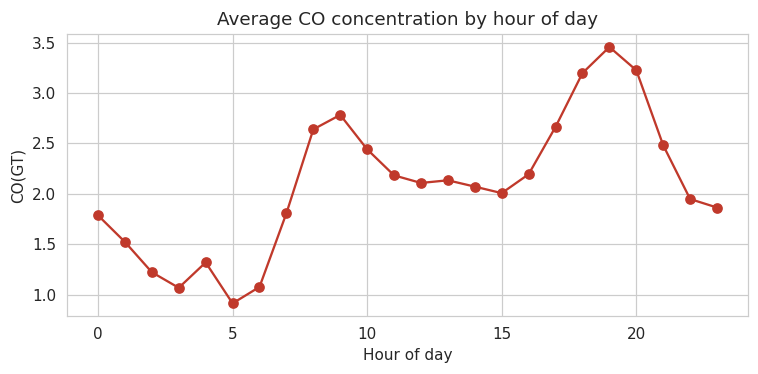

In [9]:
import matplotlib.pyplot as plt
import os

# Create the figures directory if it doesn't exist
os.makedirs("figures", exist_ok=True)

# How does CO change over the 24 hours of a day? (average per hour)
hourly = df.groupby("Hour")["CO(GT)"].mean()
plt.figure(figsize=(7,3.5))
plt.plot(hourly.index, hourly.values, marker="o", color="#c0392b")
plt.title("Average CO concentration by hour of day")
plt.xlabel("Hour of day"); plt.ylabel("CO(GT)")
plt.tight_layout()
plt.savefig("figures/eda_hourly_co.png", dpi=130, bbox_inches="tight")
plt.show()

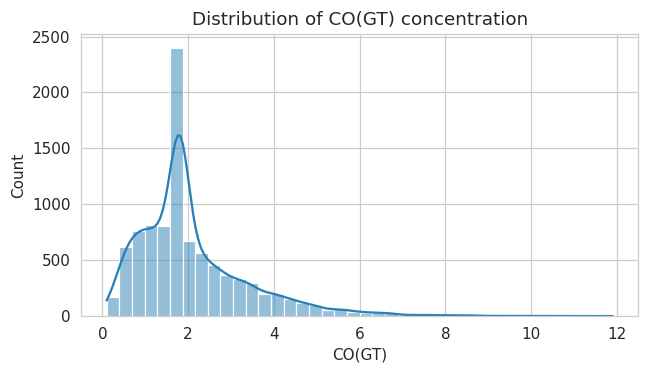

In [10]:
import seaborn as sns

# Distribution (shape) of CO values
plt.figure(figsize=(6,3.5))
sns.histplot(df["CO(GT)"], bins=40, kde=True, color="#2980b9")
plt.title("Distribution of CO(GT) concentration")
plt.xlabel("CO(GT)")
plt.tight_layout()
plt.savefig("figures/eda_co_dist.png", dpi=130, bbox_inches="tight")
plt.show()

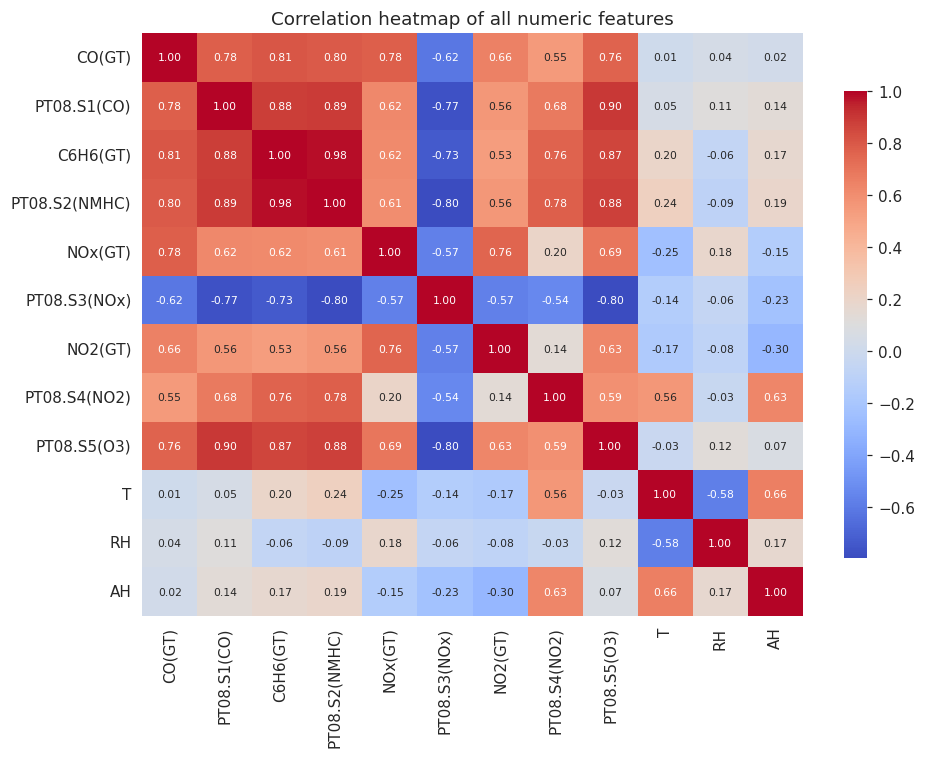

In [11]:
# Correlation heatmap: which columns move together?
plt.figure(figsize=(9,7))
corr = df.drop(columns=["Hour","Month"]).select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            annot_kws={"size":7}, cbar_kws={"shrink":0.8})
plt.title("Correlation heatmap of all numeric features")
plt.tight_layout()
plt.savefig("figures/eda_corr.png", dpi=130, bbox_inches="tight")
plt.show()

**Reading the heatmap:** values close to **+1** (red) or **−1** (blue) mean two columns
are strongly related. `CO(GT)` is strongly related to the sensor `PT08.S1(CO)` and to other
pollutants — exactly the signals our model will use to predict it.

## Step 5 — Feature selection (choose the inputs)
- **Target (what we predict):** `CO(GT)` — the true CO concentration.
- **Features (inputs):** the five metal-oxide sensor responses, the other pollutants,
  temperature, humidity, and the time features `Hour` and `Month`.

We drop text/time columns the model can't read directly.

In [12]:
target = "CO(GT)"
drop_cols = ["Date","Time","Datetime", target]
X = df.drop(columns=drop_cols)   # features (inputs)
y = df[target]                   # target  (output)

print("We will predict:", target)
print("Number of input features:", X.shape[1])
print("Features used:", list(X.columns))

We will predict: CO(GT)
Number of input features: 13
Features used: ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Hour', 'Month']


## Step 6 — Split into training and testing sets
We teach the model on **80%** of the data (training) and check it on the unseen **20%**
(testing). This proves the model really learned, instead of just memorising.
We also **scale** the features so every column is on a comparable range.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # learn scale on training data
X_test_s  = scaler.transform(X_test)        # apply same scale to test data

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 7485
Testing rows : 1872


## Step 7 — Train the Machine-Learning models
We train **three** models so we can compare them:
1. **Linear Regression** — simple straight-line relationship (our baseline).
2. **Decision Tree** — a flow-chart of yes/no questions.
3. **Random Forest** — many decision trees combined (usually the most accurate).

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree":      DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest":      RandomForestRegressor(n_estimators=150, random_state=42),
}

trained = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)   # <-- this is the actual "learning" step
    trained[name] = model
    print(f"Trained: {name}")

Trained: Linear Regression
Trained: Decision Tree
Trained: Random Forest


## Step 8 — Evaluate the models
For regression (predicting a number) we use three standard scores:
- **R² (R-squared):** how much of the variation the model explains. Closer to **1.0** = better.
- **MAE (Mean Absolute Error):** average size of the mistake. **Lower** = better.
- **RMSE (Root Mean Squared Error):** like MAE but punishes big mistakes more. **Lower** = better.

In [15]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

rows = []
for name, model in trained.items():
    pred = model.predict(X_test_s)
    r2   = r2_score(y_test, pred)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    rows.append([name, round(r2,3), round(mae,3), round(rmse,3)])

results = pd.DataFrame(rows, columns=["Model","R2","MAE","RMSE"])
results = results.sort_values("R2", ascending=False).reset_index(drop=True)
results

,Model,R2,MAE,RMSE
0,Random Forest,0.905,0.259,0.421
1,Linear Regression,0.834,0.379,0.557
2,Decision Tree,0.815,0.346,0.589


/tmp/ipykernel_1618/319832677.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="R2", palette="viridis")


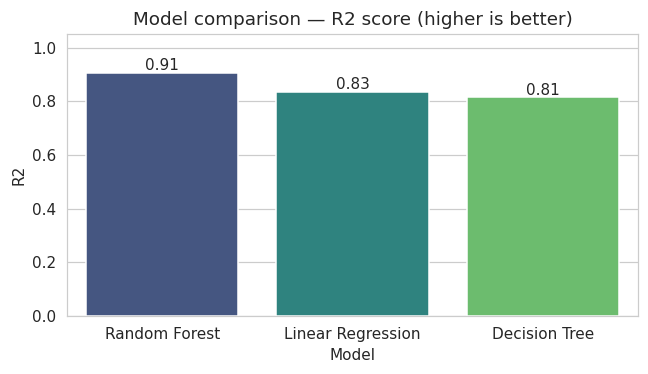

Best model: Random Forest


In [16]:
# Compare the three models visually (R2 score)
plt.figure(figsize=(6,3.5))
sns.barplot(data=results, x="Model", y="R2", palette="viridis")
plt.title("Model comparison — R2 score (higher is better)")
plt.ylim(0,1.05)
for i,v in enumerate(results["R2"]):
    plt.text(i, v+0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.savefig("figures/model_compare.png", dpi=130, bbox_inches="tight")
plt.show()

best_name = results.iloc[0]["Model"]
best_model = trained[best_name]
print("Best model:", best_name)

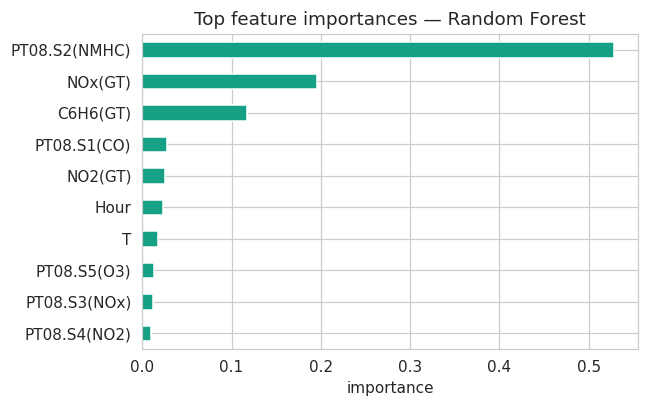

In [17]:
# Which features did the best model rely on most? (Random Forest gives this)
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=X.columns)
    imp = imp.sort_values(ascending=True).tail(10)
    plt.figure(figsize=(6,3.8))
    imp.plot.barh(color="#16a085")
    plt.title(f"Top feature importances — {best_name}")
    plt.xlabel("importance")
    plt.tight_layout()
    plt.savefig("figures/feature_importance.png", dpi=130, bbox_inches="tight")
    plt.show()

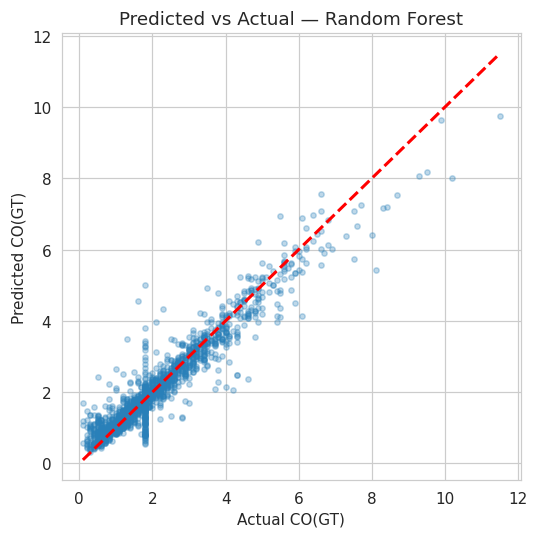

In [18]:
# Predicted vs Actual: points near the red line = good predictions
best_pred = best_model.predict(X_test_s)
plt.figure(figsize=(5,5))
plt.scatter(y_test, best_pred, alpha=0.3, s=12, color="#2980b9")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", lw=2)
plt.xlabel("Actual CO(GT)"); plt.ylabel("Predicted CO(GT)")
plt.title(f"Predicted vs Actual — {best_name}")
plt.tight_layout()
plt.savefig("figures/pred_vs_actual.png", dpi=130, bbox_inches="tight")
plt.show()

## Step 9 — Make a prediction on a new reading
This shows how the finished model would be used in practice: give it one hour's sensor +
weather readings, and it returns the predicted CO concentration.

In [19]:
# take the first test sample as an "incoming new reading"
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)
predicted_co = best_model.predict(sample_scaled)[0]

print("Input reading (sensor + weather):")
print(sample.T.to_string(header=False))
print(f"\nPredicted CO(GT): {predicted_co:.2f}")
print(f"Actual    CO(GT): {y_test.iloc[0]:.2f}")

Input reading (sensor + weather):
PT08.S1(CO)     933.0000
C6H6(GT)          6.4000
PT08.S2(NMHC)   831.0000
NOx(GT)         105.0000
PT08.S3(NOx)    888.0000
NO2(GT)          72.0000
PT08.S4(NO2)   1514.0000
PT08.S5(O3)     710.0000
T                26.0000
RH               34.9000
AH                1.1509
Hour             15.0000
Month             7.0000

Predicted CO(GT): 1.24
Actual    CO(GT): 1.30


## Step 10 — Conclusion
- We cleaned one year of real air-quality sensor data (handled the `-200` missing code and
  dropped the unusable `NMHC` column).
- We explored the data and found clear daily pollution patterns and strong sensor–pollutant
  correlations.
- We trained and compared three models. The **Random Forest** gave the best accuracy,
  confirming the finding in recent research that ensemble/tree methods work very well on this
  dataset.
- The final model predicts CO concentration from cheap sensor signals — useful for low-cost
  air-quality monitoring.

**Future improvements:** add time-series models (LSTM), predict an overall Air Quality Index
*category* (Good / Moderate / Unhealthy), and tune the model with cross-validation.